In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [4]:
data=pd.read_csv('insurance.csv')

In [5]:
data

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


## EDA


In [7]:
data.shape

(1338, 7)

In [15]:
data.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [12]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [13]:
data.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [14]:
data.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

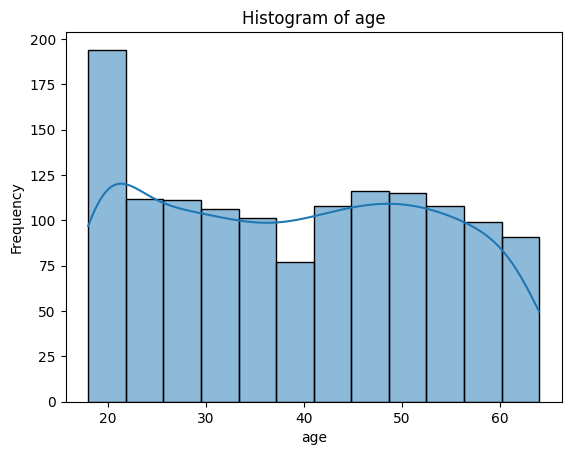

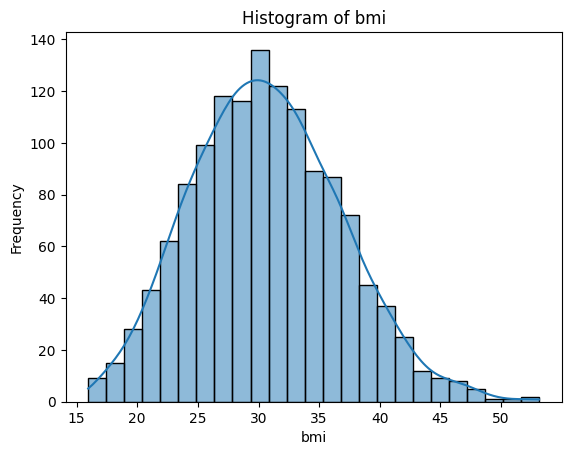

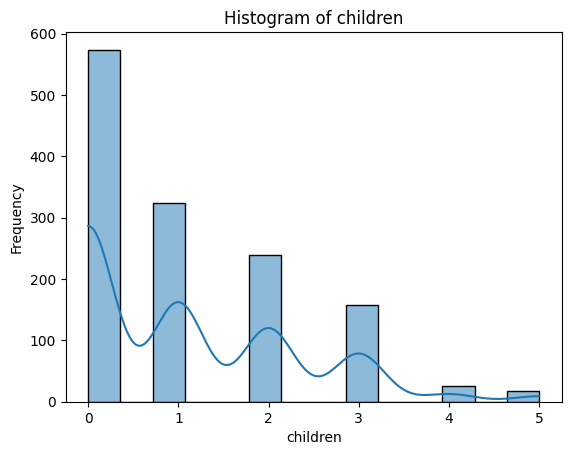

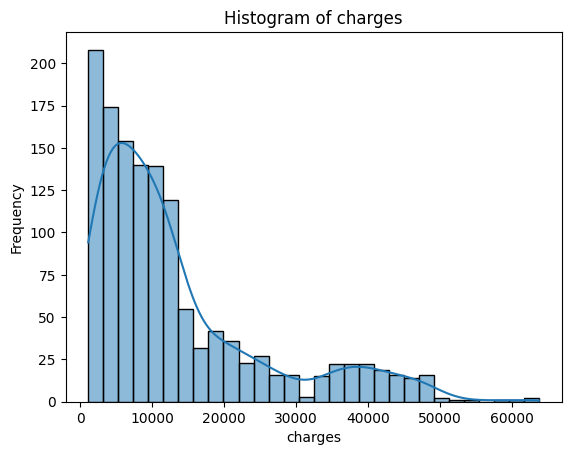

In [16]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load data
data = pd.read_csv('insurance.csv')

# Select numerical columns
num_cols = data.select_dtypes(include=['int64', 'float64']).columns

# Plot histograms
for col in num_cols:
    plt.figure()
    sns.histplot(data[col], kde=True)
    plt.title(f'Histogram of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

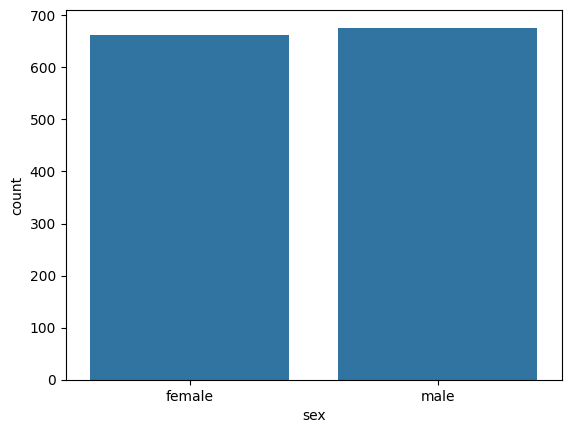

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='sex', data=data)
plt.show()

<Axes: xlabel='smoker', ylabel='count'>

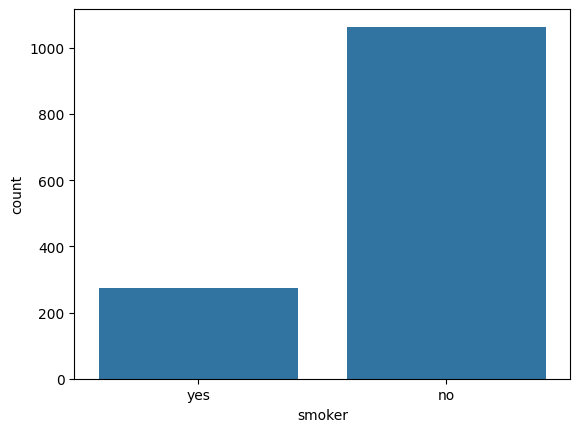

In [18]:
sns.countplot(x='smoker', data=data)

<Axes: xlabel='region', ylabel='count'>

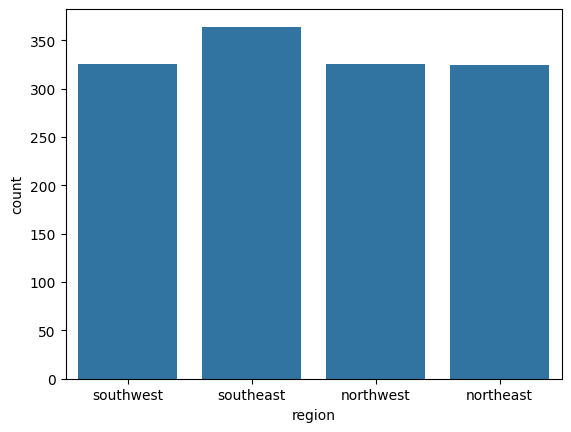

In [19]:
sns.countplot(x='region', data=data)

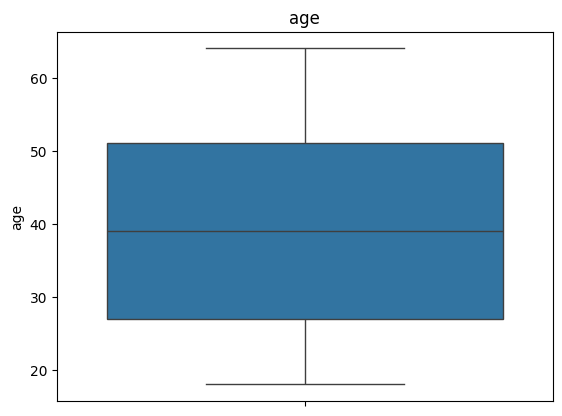

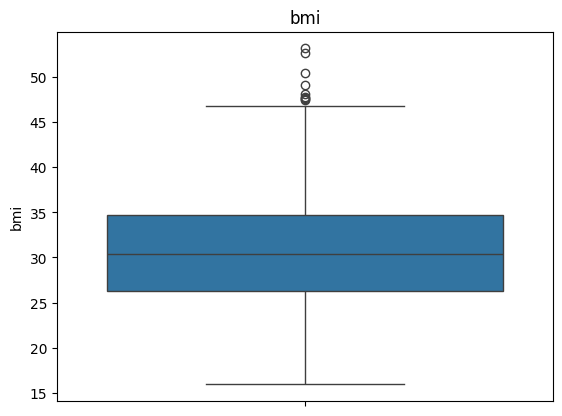

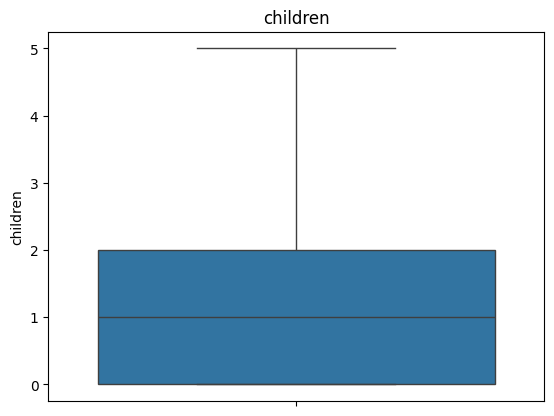

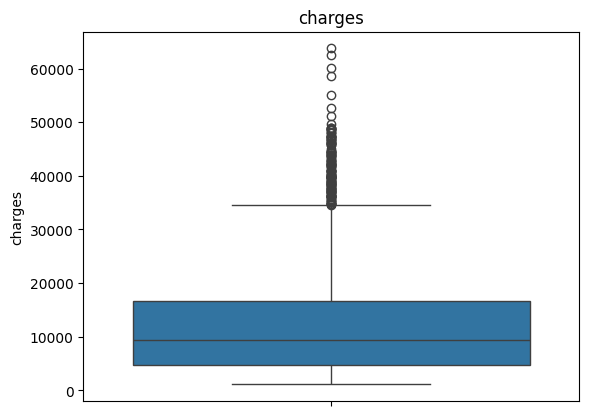

In [20]:
for col in ['age', 'bmi', 'children', 'charges']:
    sns.boxplot(y=data[col])
    plt.title(col)
    plt.show()

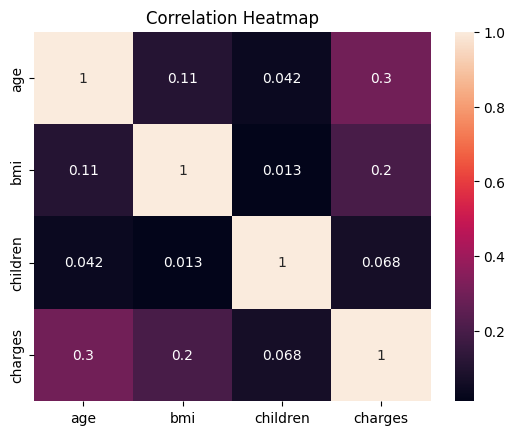

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = data.corr(numeric_only=True)

sns.heatmap(corr, annot=True)
plt.title("Correlation Heatmap")
plt.show()

## Data Cleaning and Data Preprocessing

In [22]:
data.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [23]:
data.duplicated().sum()
data.drop_duplicates(inplace=True)

In [24]:
data.dtypes

age           int64
sex          object
bmi         float64
children      int64
smoker       object
region       object
charges     float64
dtype: object

In [25]:
import pandas as pd

# Load data
data = pd.read_csv('insurance.csv')

# Convert categorical columns to numerical
data = pd.get_dummies(data, columns=['sex', 'smoker', 'region'], drop_first=True)

# View result
print(data.head())

   age     bmi  children      charges  sex_male  smoker_yes  region_northwest  \
0   19  27.900         0  16884.92400     False        True             False   
1   18  33.770         1   1725.55230      True       False             False   
2   28  33.000         3   4449.46200      True       False             False   
3   33  22.705         0  21984.47061      True       False              True   
4   32  28.880         0   3866.85520      True       False              True   

   region_southeast  region_southwest  
0             False              True  
1              True             False  
2              True             False  
3             False             False  
4             False             False  


In [27]:
data.dtypes

age                   int64
bmi                 float64
children              int64
charges             float64
sex_male               bool
smoker_yes             bool
region_northwest       bool
region_southeast       bool
region_southwest       bool
dtype: object

In [28]:
print(data.head())
print(data.columns)

   age     bmi  children      charges  sex_male  smoker_yes  region_northwest  \
0   19  27.900         0  16884.92400     False        True             False   
1   18  33.770         1   1725.55230      True       False             False   
2   28  33.000         3   4449.46200      True       False             False   
3   33  22.705         0  21984.47061      True       False              True   
4   32  28.880         0   3866.85520      True       False              True   

   region_southeast  region_southwest  
0             False              True  
1              True             False  
2              True             False  
3             False             False  
4             False             False  
Index(['age', 'bmi', 'children', 'charges', 'sex_male', 'smoker_yes',
       'region_northwest', 'region_southeast', 'region_southwest'],
      dtype='object')


In [29]:
data=data.astype(int)

In [30]:
data.head()

,age,bmi,children,charges,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27,0,16884,0,1,0,0,1
1,18,33,1,1725,1,0,0,1,0
2,28,33,3,4449,1,0,0,1,0
3,33,22,0,21984,1,0,1,0,0
4,32,28,0,3866,1,0,1,0,0


## Feature Engineering and Extraction

In [31]:
data['bmi_category'] = pd.cut(
    data['bmi'],
    bins=[0,18.5,25,30,100],
    labels=['underweight','normal','overweight','obese']
)

In [32]:
data['age_group'] = pd.cut(
    data['age'],
    bins=[0,20,40,60,100],
    labels=['young','adult','middle','senior']
)

In [33]:
data.head

<bound method NDFrame.head of       age  bmi  children  charges  sex_male  smoker_yes  region_northwest  \
0      19   27         0    16884         0           1                 0   
1      18   33         1     1725         1           0                 0   
2      28   33         3     4449         1           0                 0   
3      33   22         0    21984         1           0                 1   
4      32   28         0     3866         1           0                 1   
...   ...  ...       ...      ...       ...         ...               ...   
1333   50   30         3    10600         1           0                 1   
1334   18   31         0     2205         0           0                 0   
1335   18   36         0     1629         0           0                 0   
1336   21   25         0     2007         0           0                 0   
1337   61   29         0    29141         0           1                 1   

      region_southeast  region_southwest bmi_

In [34]:
data = pd.get_dummies(data, columns=['bmi_category'], drop_first=True)

In [35]:
data = pd.get_dummies(data, columns=['age_group'], drop_first=True)


In [37]:
data.head()

,age,bmi,children,charges,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest,bmi_category_normal,bmi_category_overweight,bmi_category_obese,age_group_adult,age_group_middle,age_group_senior
0,19,27,0,16884,0,1,0,0,1,False,True,False,False,False,False
1,18,33,1,1725,1,0,0,1,0,False,False,True,False,False,False
2,28,33,3,4449,1,0,0,1,0,False,False,True,True,False,False
3,33,22,0,21984,1,0,1,0,0,True,False,False,True,False,False
4,32,28,0,3866,1,0,1,0,0,False,True,False,True,False,False


In [39]:
data=data.astype(int)

In [40]:
data.head()

,age,bmi,children,charges,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest,bmi_category_normal,bmi_category_overweight,bmi_category_obese,age_group_adult,age_group_middle,age_group_senior
0,19,27,0,16884,0,1,0,0,1,0,1,0,0,0,0
1,18,33,1,1725,1,0,0,1,0,0,0,1,0,0,0
2,28,33,3,4449,1,0,0,1,0,0,0,1,1,0,0
3,33,22,0,21984,1,0,1,0,0,1,0,0,1,0,0
4,32,28,0,3866,1,0,1,0,0,0,1,0,1,0,0


In [45]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Split input and target
X = data.drop('charges', axis=1)
y = data['charges']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Columns to scale
cols = ['age', 'bmi']

# Create scaler
scaler = StandardScaler()

# Apply scaling ONLY on age and bmi
X_train[cols] = scaler.fit_transform(X_train[cols])
X_test[cols] = scaler.transform(X_test[cols])

In [46]:
data

,age,bmi,children,charges,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest,bmi_category_normal,bmi_category_overweight,bmi_category_obese,age_group_adult,age_group_middle,age_group_senior
0,19,27,0,16884,0,1,0,0,1,0,1,0,0,0,0
1,18,33,1,1725,1,0,0,1,0,0,0,1,0,0,0
2,28,33,3,4449,1,0,0,1,0,0,0,1,1,0,0
3,33,22,0,21984,1,0,1,0,0,1,0,0,1,0,0
4,32,28,0,3866,1,0,1,0,0,0,1,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1333,50,30,3,10600,1,0,1,0,0,0,1,0,0,1,0
1334,18,31,0,2205,0,0,0,0,0,0,0,1,0,0,0
1335,18,36,0,1629,0,0,0,1,0,0,0,1,0,0,0
1336,21,25,0,2007,0,0,0,0,1,1,0,0,1,0,0


In [47]:
print(X_train[['age', 'bmi']].head())

           age       bmi
717   1.496482 -1.015055
1040 -0.284648 -0.354606
716   0.712785 -1.345279
307  -0.640874  0.470956
100   0.142823  0.140731


In [48]:
from scipy.stats import chi2_contingency
import pandas as pd

# Create contingency table
table = pd.crosstab(data['sex_male'], data['smoker_yes'])

# Apply chi-square test
chi2, p, dof, expected = chi2_contingency(table)

print("P-value:", p)

P-value: 0.006548143503580697


In [49]:
data.corr()['charges'].sort_values(ascending=False)

charges                    1.000000
smoker_yes                 0.787251
age                        0.299009
bmi                        0.196188
bmi_category_obese         0.190052
age_group_middle           0.179588
age_group_senior           0.173899
region_southeast           0.073981
children                   0.067999
sex_male                   0.057293
region_northwest          -0.039905
region_southwest          -0.043210
bmi_category_overweight   -0.082547
bmi_category_normal       -0.121151
age_group_adult           -0.174215
Name: charges, dtype: float64

In [50]:
from sklearn.feature_selection import f_regression
import pandas as pd

X = data.drop('charges', axis=1)
y = data['charges']

f_values, p_values = f_regression(X, y)

results = pd.DataFrame({
    'Feature': X.columns,
    'P-value': p_values
}).sort_values(by='P-value')

print(results)

                    Feature        P-value
4                smoker_yes  8.285498e-283
0                       age   4.885626e-29
1                       bmi   4.484310e-13
10       bmi_category_obese   2.394276e-12
12         age_group_middle   3.670035e-11
11          age_group_adult   1.401599e-10
13         age_group_senior   1.514599e-10
8       bmi_category_normal   8.838883e-06
9   bmi_category_overweight   2.512680e-03
6          region_southeast   6.783248e-03
2                  children   1.285094e-02
3                  sex_male   3.612846e-02
7          region_southwest   1.141499e-01
5          region_northwest   1.445917e-01


In [51]:
important = results[results['P-value'] < 0.05]['Feature']
X = X[important]

In [52]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [53]:
y_pred = model.predict(X_test)

In [54]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

print("R2 Score:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))

R2 Score: 0.7395973672818881
MAE: 4397.934197497902
MSE: 38566843.873520084
